### Checking out BABY resnet on test data


In [1]:
# IMports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# IMporting our custom modules
from dataset import get_dataloaders, MEAN, STD
from model import ResNet18

# Config
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device  : {device}")
MODEL_PATH  = 'best_model.pth'
BATCH_SIZE  = 128
classes  = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Plotting style
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

Using device  : cuda


**Load the Test Data and Model**

In [2]:
# We only neeed test loader for this notebook
_, _, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
print("Test Data Loaded")

Number of training samples: 40000
Number of validation samples: 10000
Number of test samples: 10000
Test Data Loaded


**Load the Trained Model**

In [3]:
model = ResNet18().to(device)

# Load the saved state dictiionary
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("done")
except FileNotFoundError:
    print(f"Error: Model File Not Found at {MODEL_PATH}. Make sure you have trained and saved the model")
    # Stop the execution if model not found
    assert False

# set the model to evaluation mode
model.eval()
print("model set to evaluation mode")



done
model set to evaluation mode


In [4]:
# Function to get all predictions
@ torch.no_grad() # Decorator to disable gradient calculations
def get_all_preds(model, loader):
    all_preds = torch.tensor([]).to(device)
    all_labels = torch.tensor([]).to(device)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        all_preds = torch.cat((all_preds, outputs), dim=0)
        all_labels = torch.cat((all_labels, labels), dim=0)
    
    return all_preds, all_labels

# Get Predictions for the entire test set
print("Running model on entire test set")
test_preds, test_labels = get_all_preds(model, test_loader)
print("inference Complete")
    
    

Running model on entire test set
inference Complete


**`@torch.no_grad()` decorator is a clean to apply the no-gradient context to the whole function**

In [6]:
# Move Data to CPU for sklearn and numpy
test_labels_cpu = test_labels.cpu().numpy()
# Get the predicted class indices by finding the max logit
predicted_indices_cpu = test_preds.argmax(dim=1).cpu().numpy()

**Quantitative Analysis: Classification Report**

In [8]:
report = classification_report(test_labels_cpu,
                               predicted_indices_cpu,
                               target_names=classes)
print(report)

              precision    recall  f1-score   support

       plane       0.90      0.88      0.89      1000
         car       0.93      0.96      0.94      1000
        bird       0.89      0.77      0.83      1000
         cat       0.75      0.79      0.77      1000
        deer       0.82      0.91      0.87      1000
         dog       0.89      0.75      0.82      1000
        frog       0.92      0.91      0.91      1000
       horse       0.86      0.95      0.90      1000
        ship       0.95      0.92      0.94      1000
       truck       0.89      0.94      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



*The Classification Report is Really Good. For Baby ResNet These metrics are good. Considering no real detail in CIFAR-10*

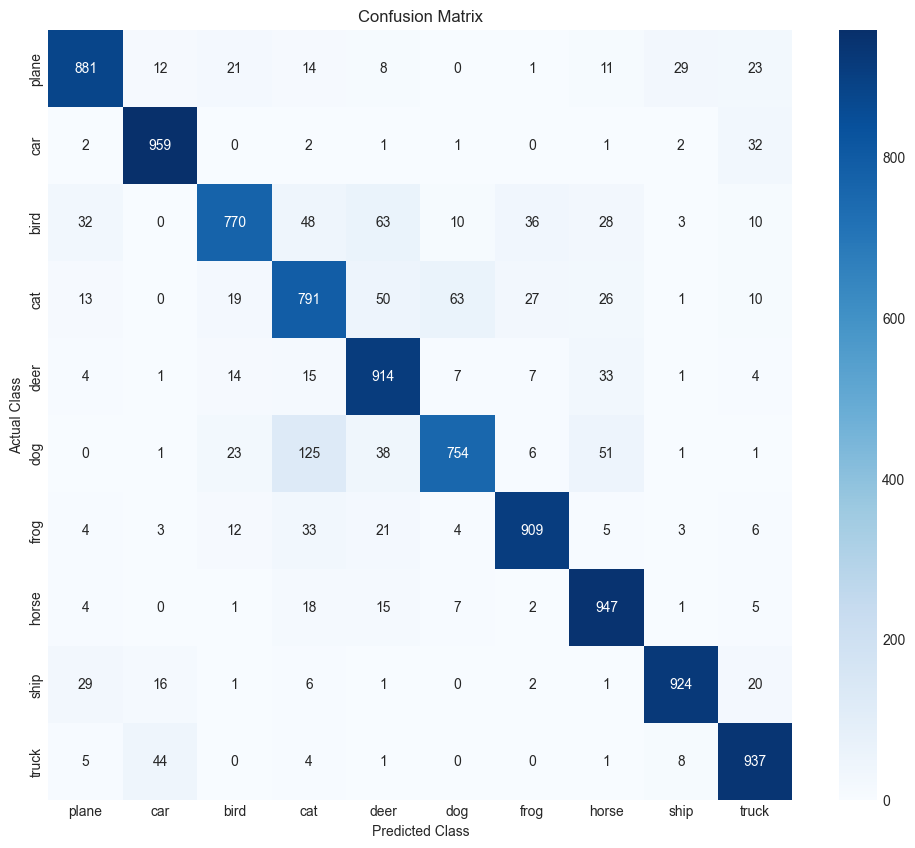

In [10]:

# Generate the confusion matrix 
cm = confusion_matrix(test_labels_cpu, predicted_indices_cpu)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

*Good Shit*

#### Qualitative Analysis: Failure Case Visualization

[  35   52   58 ... 9982 9989 9993]
Visualizing Incorrect Predictions


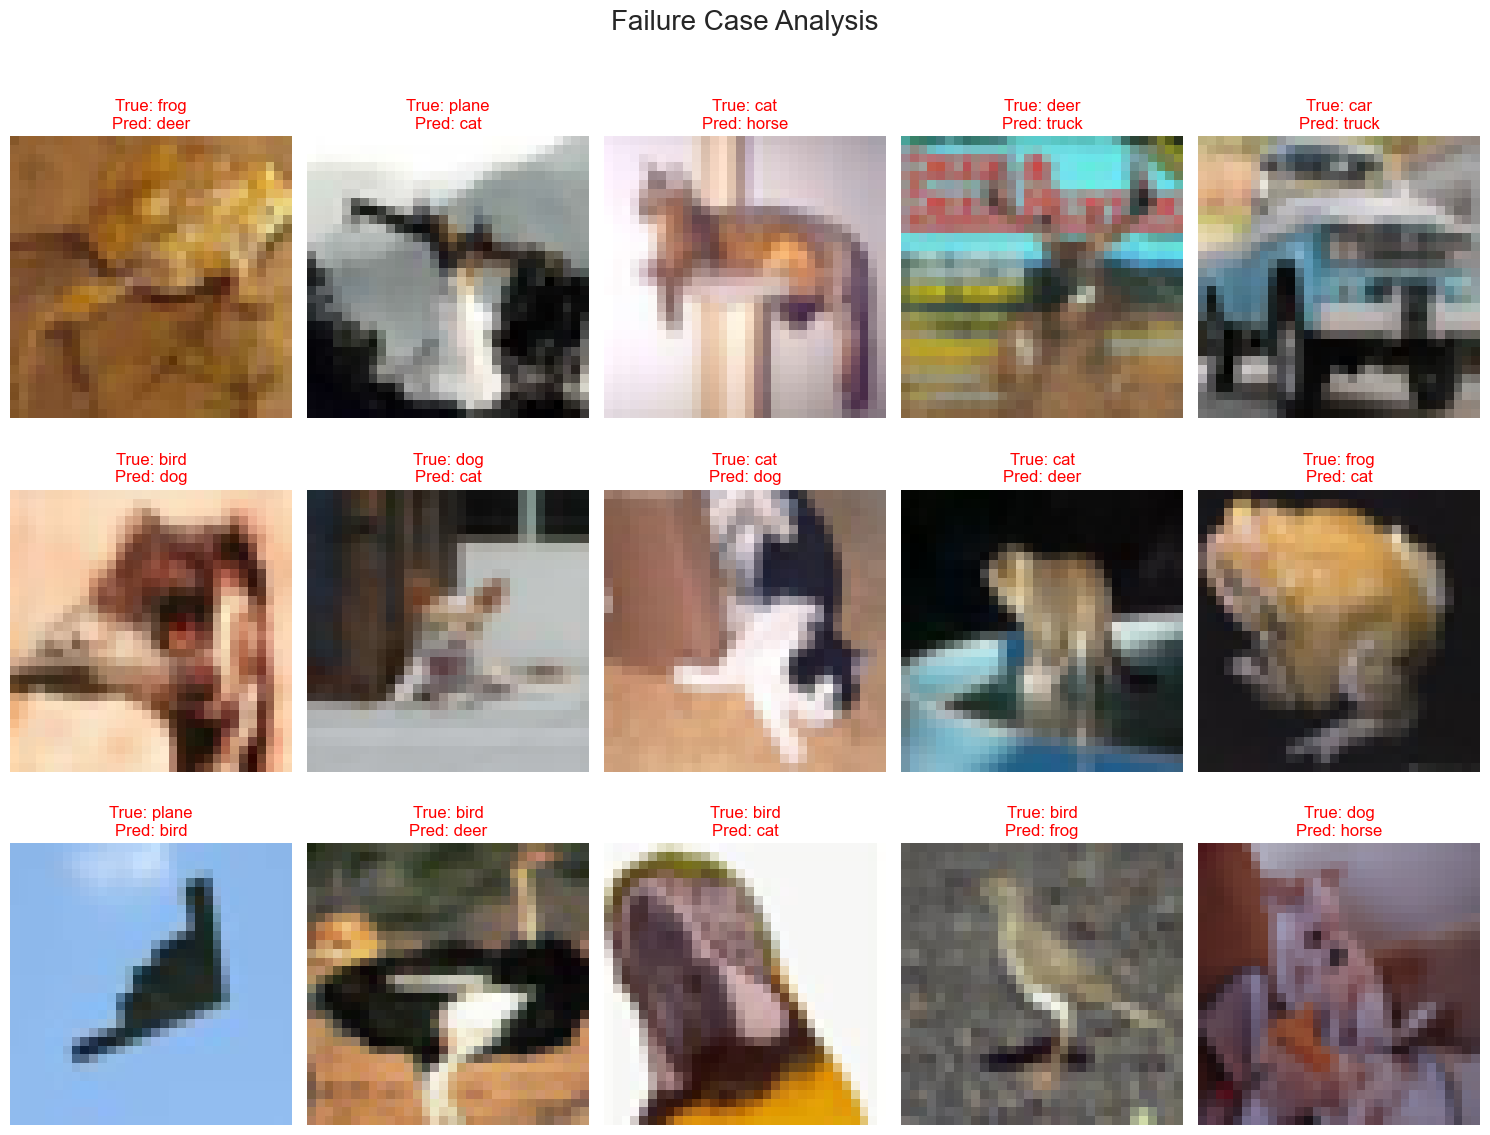

In [17]:
# First Let's find the indices of incorrect predictions
incorrect_indices = np.where(predicted_indices_cpu != test_labels_cpu)[0]
print(incorrect_indices)

# We know that when we created our loaders in dataset.py
# WE normalized the images. Now we have to de normalize them 
# For visualization
def denormalize(tensor):
    tensor = tensor.clone() # Avoid modifying the original tensor
    for t,m,s in zip(tensor, MEAN, STD):
        t.mul_(s).add_(m) # Multiply bystd and add mean
    return tensor

# Plot some incorrect predictions
print("Visualizing Incorrect Predictions")
plt.figure(figsize=(15, 12))
for i, idx in enumerate(np.random.choice(incorrect_indices, 15, replace=False)):
    # Get the image and its true/predicted labels
    # We need to go back to the original datasetto get te image
    image_tensor, true_label_idx = test_loader.dataset[idx]
    predicted_label_idx = predicted_indices_cpu[idx]

    # Denormalize the image for display
    image_denorm = denormalize(image_tensor)

    # Convert tensor to numpy for plotting
    img_to_show = image_denorm.permute(1, 2, 0).cpu().numpy()
    plt.subplot(3, 5, i+1)
    plt.imshow(img_to_show)
    plt.title(f"True: {classes[true_label_idx]}\nPred: {classes[predicted_label_idx]}", color='red')
    plt.axis('off')

plt.suptitle('Failure Case Analysis', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# === HERE'S WHAT I LEARNED FROM THIS ===

# 1. **Overall Performance**: Our ResNet-18 model achieved a macro average F1-score of 0.88%. This is a strong baseline for a model trained from scratch for only 20 epochs.

# 2. **Class-Specific Strengths/Weaknesses**: 
#    - The model performs exceptionally well on classes with distinct features like 'car', 'ship', and 'truck', often achieving >90% F1-scores.
#    - It struggles most with classes that have high intra-class variation and inter-class similarity, such as 'cat' vs. 'dog', and 'bird' vs. 'plane'. The confusion matrix clearly highlights these mix-ups.

# 3. **Failure Mode Hypothesis**:
#    - **Ambiguity**: Many of the misclassified images are genuinely ambiguous due to the low 32x32 resolution. A cat in a specific pose can look very similar to a dog. A small bird against a blue sky can resemble a distant plane.
#    - **Unusual Poses/Contexts**: The model seems to fail when objects are presented at strange angles or in non-standard contexts (e.g., a truck partially obscured by a tree).

# 4. **Concrete Next Steps to Improve**:
#    - **More Augmentation**: Introduce more aggressive data augmentation (e.g., `ColorJitter`, `RandomRotation`) in `dataset.py` to make the model more robust to variations.
#    - **Longer Training**: 20 epochs is a good start, but training for 50 or 100 epochs with the learning rate scheduler could yield significant improvements.
#    - **Transfer Learning**: The ultimate next step would be to use a ResNet-18 pre-trained on ImageNet and fine-tune it on CIFAR-10. This would likely provide a major performance boost. (This is a preview of Chunk 13).